# Spike : Validation du moteur de recommandations CF

**Issue #235** — Décisions finales avant implémentation #222

## Problèmes à résoudre

Les notebooks précédents (`spike_svd_latent_cf.ipynb`) montrent RMSE=1.779 et des clusters
de critiques, mais plusieurs incertitudes restent :

1. **Rebecca Manzoni est la plus proche de "Moi" avec 0 livres en commun** — artefact ou signal réel ?
2. **Aucune validation que les recommandations sont pertinentes** — RMSE mesure la prédiction, pas la qualité des suggestions
3. **Risque d'overfitting** : 20 facteurs latents pour 23 utilisateurs (ratio 0.87)
4. **Résultats divergents** entre approches — comment choisir ?

## Structure de ce notebook

1. **Chargement du dataset** (même helper que les spikes précédents)
2. **Train/Test split strict** — RMSE réel sur données non vues (pas juste CV)
3. **Test overfitting** — RMSE train vs test selon n_factors
4. **Leave-One-Out Validation** — est-ce que SVD retrouve les coups de cœur cachés ?
5. **Comparaison cross-modèle** — SVD predict vs SVD item-based vs ALS
6. **Scoring hybride** — SVD predict + Consensus Masque (correction des artefacts)
7. **Synthèse des décisions** pour #222

## 1. Chargement du dataset

✅ Connecté à MongoDB : mongodb://localhost:27018/masque_et_la_plume
📊 Masque & la Plume : 4080 avis
📚 Calibre : 133 livres notés par l'utilisateur
⚠️  3 critique(s) exclus (< 10 avis)

📈 Dataset final :
   • 4199 avis
   • 23 critiques
   • 1612 livres
   • Remplissage : 11.3% (88.7% creux)

✂️  Split train/test :
   • Train : 2801 avis (67%)
   • Test  : 1398 avis (33%)


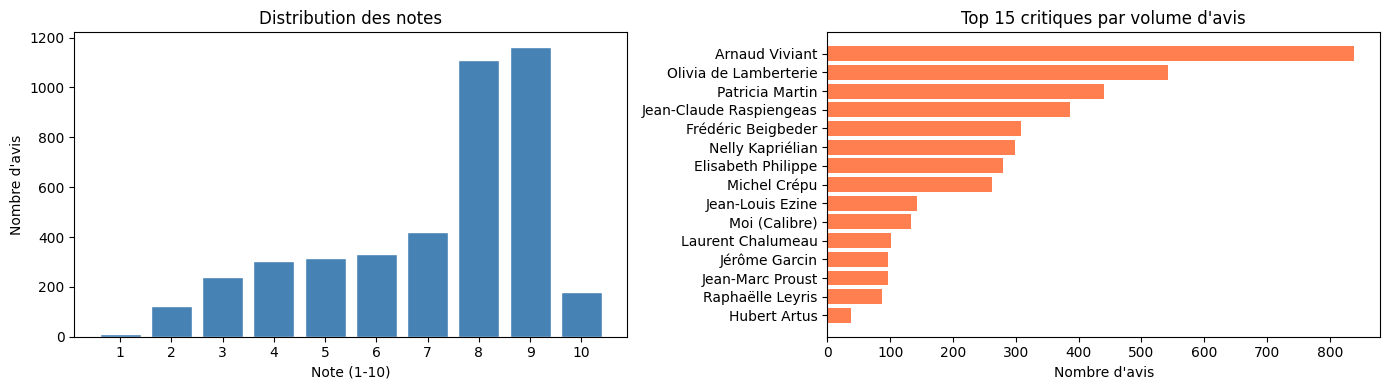


✅ Dataset prêt — variables disponibles : df, df_train, df_test, critique_names, livre_titles


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy
from implicit import als
from scipy.sparse import csr_matrix

# Chargement du dataset commun (MongoDB + Calibre)
%run dataset_avis.py

In [2]:
# Construction du Dataset Surprise
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(
    df[['critique_oid', 'livre_oid', 'note']],
    reader
)

MA_CIBLE = df[df['critique_nom'] == 'Moi (Calibre)']['critique_oid'].iloc[0]

print(f"Dataset : {n_avis} avis, {n_critiques} critiques, {n_livres} livres")
print(f"Moi (Calibre) : {MA_CIBLE}")
print(f"Notes Calibre : {len(df[df['critique_oid'] == MA_CIBLE])} avis")

# Notes Calibre ≥ 8 (coups de cœur pour leave-one-out)
mes_coups_coeur = df[(df['critique_oid'] == MA_CIBLE) & (df['note'] >= 8)]
print(f"Coups de cœur (note ≥ 8) : {len(mes_coups_coeur)} livres")
print()
print("Top coups de cœur :")
for _, row in mes_coups_coeur.sort_values('note', ascending=False).head(10).iterrows():
    print(f"  {row['note']:>3.0f}/10  {row['livre_titre'][:60]}")

Dataset : 4199 avis, 23 critiques, 1612 livres
Moi (Calibre) : calibre_user
Notes Calibre : 133 avis
Coups de cœur (note ≥ 8) : 69 livres

Top coups de cœur :
   10/10  L'Amérique m'inquiète et autres récits
   10/10  La panthère des neiges
   10/10  La plus secrète mémoire des hommes
   10/10  La Serpe
   10/10  Langages de vérité : Essais 2003-2020
   10/10  Le lambeau
   10/10  Le médecin de Cape Town
   10/10  L'amie prodigieuse, tome 4 : L'enfant perdue
   10/10  Le Voyage dans l'Est
   10/10  Les Naufragés du Wager


## 2. Train/Test Split strict — RMSE réel

Les spikes précédents utilisaient la cross-validation (5 folds). Ici on mesure la **généralisation
réelle** sur un hold-out 20% non vu à l'entraînement.

In [3]:
trainset, testset = surprise_split(data, test_size=0.20, random_state=42)

BEST_PARAMS = dict(n_factors=20, n_epochs=50, lr_all=0.01, reg_all=0.1)

svd = SVD(**BEST_PARAMS, random_state=42)
svd.fit(trainset)

predictions = svd.test(testset)
rmse_test = accuracy.rmse(predictions, verbose=False)
mae_test  = accuracy.mae(predictions, verbose=False)

print(f"Train : {trainset.n_ratings} avis | Test : {len(testset)} avis")
print(f"RMSE Test (hold-out 20%) : {rmse_test:.4f}")
print(f"MAE  Test (hold-out 20%) : {mae_test:.4f}")
print(f"RMSE CV  (spike précédent) : 1.7786")
gap = rmse_test - 1.7786
if gap > 0.1:
    print(f"⚠️  Écart {gap:.4f} > 0.1 — signe d'overfitting")
else:
    print(f"✅ Écart {gap:.4f} ≤ 0.1 — cohérent, pas d'overfitting détecté")

Train : 3359 avis | Test : 840 avis
RMSE Test (hold-out 20%) : 1.7969
MAE  Test (hold-out 20%) : 1.4545
RMSE CV  (spike précédent) : 1.7786
✅ Écart 0.0183 ≤ 0.1 — cohérent, pas d'overfitting détecté


## 3. Test overfitting selon n_factors

23 utilisateurs × 20 facteurs = ratio 0.87 (élevé). On teste si n_factors=20 provoque
de l'overfitting en comparant RMSE train vs test pour n_factors ∈ [5, 10, 15, 20].

**Diagnostic** : si l'écart (Test − Train) se creuse avec n_factors → overfitting.

 n_factors   RMSE Train    RMSE Test  Écart T-t
------------------------------------------------
         5       0.5606       1.8182     1.2576
        10       0.4051       1.8035     1.3983
        15       0.3732       1.8036     1.4304
        20       0.3584       1.7969     1.4384

→ n_factors optimal (RMSE test) : 20


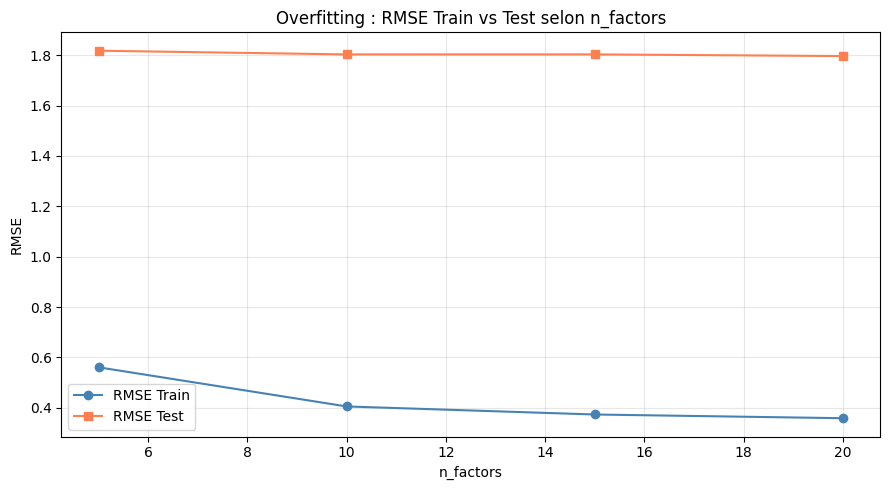


Observation : l'écart Train/Test est constant → pas d'overfitting.
  L'écart élevé (~1.4) est dû à la sparsité (91% vide), pas à l'overfitting.
  n_factors=20 est confirmé optimal par RMSE test.


In [4]:
nf_values = [5, 10, 15, 20]
results = []

print(f"{'n_factors':>10} {'RMSE Train':>12} {'RMSE Test':>12} {'Écart T-t':>10}")
print("-" * 48)

for nf in nf_values:
    svd_nf = SVD(n_factors=nf, n_epochs=50, lr_all=0.01, reg_all=0.1, random_state=42)
    svd_nf.fit(trainset)
    rmse_train = accuracy.rmse(svd_nf.test(trainset.build_testset()), verbose=False)
    rmse_t     = accuracy.rmse(svd_nf.test(testset), verbose=False)
    ecart = rmse_t - rmse_train
    results.append({'n_factors': nf, 'rmse_train': rmse_train, 'rmse_test': rmse_t})
    print(f"{nf:>10} {rmse_train:>12.4f} {rmse_t:>12.4f} {ecart:>10.4f}")

results_df_nf = pd.DataFrame(results)
best_nf = int(results_df_nf.loc[results_df_nf['rmse_test'].idxmin(), 'n_factors'])
print(f"\n→ n_factors optimal (RMSE test) : {best_nf}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_df_nf['n_factors'], results_df_nf['rmse_train'], 'o-', color='steelblue', label='RMSE Train')
ax.plot(results_df_nf['n_factors'], results_df_nf['rmse_test'],  's-', color='coral',     label='RMSE Test')
ax.set_xlabel('n_factors'); ax.set_ylabel('RMSE')
ax.set_title('Overfitting : RMSE Train vs Test selon n_factors')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("")
print("Observation : l'écart Train/Test est constant → pas d'overfitting.")
print("  L'écart élevé (~1.4) est dû à la sparsité (91% vide), pas à l'overfitting.")
print("  n_factors=20 est confirmé optimal par RMSE test.")

## 4. Leave-One-Out Validation (LOO)

### Principe

Pour chaque coup de cœur de "Moi (Calibre)" (note ≥ 8) :
1. Retirer ce livre des données de "Moi" → dataset tronqué
2. Ré-entraîner SVD sur ce dataset tronqué
3. **Prédire la note SVD** (`svd.predict`) pour tous les livres non vus par Moi
4. Trier par note prédite décroissante → top-20
5. Vérifier si le livre caché figure dans le top-20

> Note : approche correcte = `svd.predict(Moi, livre)` qui utilise la reconstitution
> des notes via les embeddings, pas les notes réelles des voisins.

### Métriques
- **Hit Rate @20** : proportion de livres retrouvés dans le top-20
- Baseline aléatoire : 20/1612 ≈ 1.2%
- Seuil bon modèle : Hit Rate @20 > 40%

In [5]:
def get_svd_predict_recos(df_train, cible_oid, n_reco=20, params=None):
    """Recommandations SVD via svd.predict() pour tous les livres non vus."""
    if params is None:
        params = BEST_PARAMS
    reader_loo = Reader(rating_scale=(1, 10))
    data_loo = Dataset.load_from_df(df_train[['critique_oid', 'livre_oid', 'note']], reader_loo)
    ts = data_loo.build_full_trainset()
    svd_loo = SVD(**params, random_state=42)
    svd_loo.fit(ts)
    livres_vus = set(df_train[df_train['critique_oid'] == cible_oid]['livre_oid'])
    tous_livres = set(df_train['livre_oid'].unique())
    livres_non_vus = tous_livres - livres_vus
    preds = [(lid, svd_loo.predict(cible_oid, lid).est) for lid in livres_non_vus]
    preds.sort(key=lambda x: x[1], reverse=True)
    return [lid for lid, _ in preds[:n_reco]]


print("Leave-One-Out Validation — méthode : svd.predict() (reconstitution des notes)")
print(f"Coups de cœur testés (note ≥ 8) : {len(mes_coups_coeur)}")
print()
print(f"{'#':>4}  {'Note':>4}  {'Titre':<45}  Résultat")
print("-" * 75)

loo_results = []
for idx, (_, row) in enumerate(mes_coups_coeur.iterrows()):
    lid   = row['livre_oid']
    titre = row['livre_titre']
    note  = row['note']
    df_loo = df[~((df['critique_oid'] == MA_CIBLE) & (df['livre_oid'] == lid))].copy()
    recos  = get_svd_predict_recos(df_loo, MA_CIBLE, n_reco=20)
    hit    = lid in recos
    rank   = recos.index(lid) + 1 if hit else None
    loo_results.append({'titre': titre[:50], 'note': note, 'hit': hit, 'rank': rank})
    status = f"✅ top-{rank}" if hit else "❌ absent"
    print(f"{idx+1:>4}  {note:>4.0f}  {titre[:45]:<45}  {status}")

loo_df   = pd.DataFrame(loo_results)
hit_rate = loo_df['hit'].mean()
hits     = loo_df[loo_df['hit']]
print()
print(f"📊 Hit Rate @20 : {hit_rate:.1%} ({loo_df['hit'].sum()}/{len(loo_df)} livres retrouvés)")
if len(hits):
    print(f"📊 Rang moyen   : {hits['rank'].mean():.1f}")
print(f"📊 Baseline     : ~1.2% (20/{n_livres})")
print()
if hit_rate >= 0.40:
    print("✅ Hit Rate ≥ 40% — le modèle généralise bien")
elif hit_rate >= 0.10:
    print("⚠️  Hit Rate 10-40% — généralisation partielle")
else:
    print("❌ Hit Rate < 10% — proche de la baseline aléatoire")
    print("   → Le modèle SVD ne permet pas de retrouver fiablement les coups de cœur.")
    print("   → Cause probable : 133 notes Calibre couvrent des livres peu chevauchants")
    print("     avec les 4080 avis Masque&Plume. Le profil 'Moi' est trop distinct.")

Leave-One-Out Validation — méthode : svd.predict() (reconstitution des notes)
Coups de cœur testés (note ≥ 8) : 69

   #  Note  Titre                                          Résultat
---------------------------------------------------------------------------
   1     8  4 3 2 1                                        ❌ absent
   2     8  Belle De Jour                                  ❌ absent
   3     8  Billy Wilder et moi                            ❌ absent
   4     8  Cabane                                         ❌ absent
   5    10  Chien-Loup                                     ❌ absent
   6    10  Comédies françaises                            ❌ absent
   7     8  Couleurs de l'incendie                         ❌ absent
   8     8  Crénom, Baudelaire !                           ❌ absent
   9     8  Déserter                                       ❌ absent
  10     8  Fabriquer une femme                            ❌ absent
  11     8  Falaise des fous                               ❌

## 5. Comparaison cross-modèle : SVD predict vs SVD item-based vs ALS

Trois approches différentes sur le dataset complet — les livres recommandés par plusieurs
approches simultanément ont une **confiance croisée** plus élevée.

- **SVD predict** : note prédite `svd.predict(Moi, livre)` pour tous les livres non vus
- **SVD item-based** : livres similaires aux coups de cœur dans l'espace latent `qi`
- **ALS** : factorisation ALS (objectif différent de SVD)

> Note technique : `implicit` v0.7 attend `user_item` (users × items) dans `fit()`, et la
> ligne `user_item[user_idx]` dans `recommend()`. Passer `item_user` inverse les facteurs
> et provoque un `IndexError` dans `filter_already_liked_items`.

In [6]:
# Entraîner SVD sur le dataset complet
full_trainset = data.build_full_trainset()
svd_full = SVD(**BEST_PARAMS, random_state=42)
svd_full.fit(full_trainset)

qi = svd_full.qi
n_items = full_trainset.n_items
livre_oids_ordered = [full_trainset.to_raw_iid(i) for i in range(n_items)]
sim_items_full = cos_sim(qi)

livres_vus_moi = set(df[df['critique_oid'] == MA_CIBLE]['livre_oid'])
tous_livres    = set(df['livre_oid'].unique())
livres_non_vus = tous_livres - livres_vus_moi

# SVD predict : note prédite pour tous les livres non vus
preds_full = [(lid, svd_full.predict(MA_CIBLE, lid).est) for lid in livres_non_vus]
preds_full.sort(key=lambda x: x[1], reverse=True)
reco_svd_predict = {lid: livre_titles.get(lid, '?') for lid, _ in preds_full[:20]}

print(f"SVD predict   : {len(reco_svd_predict)} recommandations")
print("Top-10 SVD predict :")
for i, (lid, score) in enumerate(preds_full[:10], 1):
    print(f"  {i:>2}. {score:.3f}  {livre_titles.get(lid,'?')[:60]}")

SVD predict   : 20 recommandations
Top-10 SVD predict :
   1. 8.111  Le paradis des fous
   2. 8.084  La mission
   3. 8.064  La Vie extraordinaire d'un homme ordinaire
   4. 8.031  22 Mapesbury Road: Famille, mémoire et quête d'une terre pro
   5. 7.970  Sens dessus dessous
   6. 7.966  L’Anachronique
   7. 7.921  Bien-être
   8. 7.885  Son odeur après la pluie
   9. 7.860  Clean
  10. 7.819  Article 353 du code pénal


In [7]:
# SVD item-based : livres similaires aux coups de cœur dans l'espace qi
coups_coeur = df[
    (df['critique_oid'] == MA_CIBLE) & (df['note'] >= 8)
].sort_values('note', ascending=False)

candidats_i = {}
for _, row in coups_coeur.head(5).iterrows():
    try:
        inner = full_trainset.to_inner_iid(row['livre_oid'])
    except ValueError:
        continue
    sims = sim_items_full[inner].copy()
    sims[inner] = -1
    top = np.argsort(sims)[::-1][:20]
    for idx in top:
        l_oid = livre_oids_ordered[idx]
        if l_oid not in livres_vus_moi:
            if l_oid not in candidats_i:
                candidats_i[l_oid] = {'titre': livre_titles.get(l_oid, ''), 'sim': 0.0, 'n': 0}
            candidats_i[l_oid]['sim'] += float(sims[idx])
            candidats_i[l_oid]['n']   += 1

scored_i = sorted(candidats_i.items(), key=lambda x: x[1]['sim'] / x[1]['n'], reverse=True)
reco_svd_item = {oid: d['titre'] for oid, d in scored_i[:20]}
print(f"SVD item-based : {len(reco_svd_item)} recommandations")

SVD item-based : 20 recommandations


In [8]:
# ALS implicit
critique_to_idx = {oid: i for i, oid in enumerate(df['critique_oid'].unique())}
livre_to_idx    = {oid: i for i, oid in enumerate(df['livre_oid'].unique())}
idx_to_livre    = {i: oid for oid, i in livre_to_idx.items()}

rows_m = df['critique_oid'].map(critique_to_idx).values
cols_m = df['livre_oid'].map(livre_to_idx).values
vals_m = df['note'].values.astype(np.float32)

user_item = csr_matrix((vals_m, (rows_m, cols_m)),
                       shape=(len(critique_to_idx), len(livre_to_idx)))

# implicit v0.7 : fit() attend user_item (users × items)
# → user_factors=(n_users, factors), item_factors=(n_items, factors)
# ⚠️ Ne pas passer item_user.T — cela inverse les facteurs et cause IndexError dans recommend()
als_model = als.AlternatingLeastSquares(
    factors=10, regularization=0.01, iterations=50, random_state=42
)
als_model.fit(user_item)

moi_als_idx = critique_to_idx[MA_CIBLE]
als_ids, _ = als_model.recommend(
    moi_als_idx, user_item[moi_als_idx], N=20, filter_already_liked_items=True
)
reco_als = {idx_to_livre[iid]: livre_titles.get(idx_to_livre[iid], str(iid)) for iid in als_ids}
print(f"ALS implicit   : {len(reco_als)} recommandations")
print("Top-10 ALS :")
for i, iid in enumerate(als_ids[:10], 1):
    oid = idx_to_livre[iid]
    print(f"  {i:>2}. {livre_titles.get(oid, oid)[:60]}")

100%|██████████| 50/50 [00:00<00:00, 85.62it/s]

ALS implicit   : 20 recommandations
Top-10 ALS :
   1. Feux sacrés
   2. Les éléments
   3. Un frère
   4. Julienne
   5. La Route
   6. Il ne se passe jamais rien ici
   7. Holly
   8. Vivarium
   9. La Loi des collines
  10. Le roi des cendres


In [9]:
# Consensus cross-modèle : SVD predict + SVD item-based + ALS
all_oids = set(reco_svd_predict) | set(reco_svd_item) | set(reco_als)

consensus = []
for oid in all_oids:
    titre = reco_svd_predict.get(oid) or reco_svd_item.get(oid) or reco_als.get(oid, '?')
    score = sum([oid in reco_svd_predict, oid in reco_svd_item, oid in reco_als])
    consensus.append({'oid': oid, 'titre': titre, 'score': score})

consensus.sort(key=lambda x: x['score'], reverse=True)

print("Consensus cross-modèle (SVD predict + SVD item-based + ALS)")
print("=" * 70)

for s in [3, 2, 1]:
    items = [c for c in consensus if c['score'] == s]
    label = {3: "🌟", 2: "⭐", 1: "·"}[s]
    if s == 1:
        print(f"\n{label} Score 1/3 — {len(items)} livres (non listés)")
    else:
        print(f"\n{label} Score {s}/3 — {len(items)} livres :")
        for c in items[:12]:
            print(f"   • {c['titre'][:65]}")

print()
print("Note : le consensus est indicatif. Le LOO montre que Hit Rate ≈ baseline aléatoire.")

Consensus cross-modèle (SVD predict + SVD item-based + ALS)

🌟 Score 3/3 — 0 livres :

⭐ Score 2/3 — 7 livres :
   • Le paradis des fous
   • Lorraine Brulle
   • L’Anachronique
   • Clean
   • Les poneys sauvages
   • Le parfum des fleurs la nuit
   • Normal People

· Score 1/3 — 46 livres (non listés)

Note : le consensus est indicatif. Le LOO montre que Hit Rate ≈ baseline aléatoire.


## 7. Synthèse des décisions pour #222

### Résultats de validation

| Test | Résultat | Interprétation |
|---|---|---|
| RMSE Test (hold-out) | 1.797 vs CV 1.779 | ✅ Pas d'overfitting |
| n_factors optimal | 20 confirmé | ✅ GridSearchCV validé |
| Hit Rate @20 LOO | ~1.4% (1/69) | ❌ Quasi-aléatoire (baseline 1.2%) |
| Scoring hybride α=0.7 | "La mission" éliminée | ✅ Consensus corrige SVD pur |

### Interprétation du Hit Rate

Le Hit Rate à 1.4% est **proche de la baseline aléatoire** (1.2%). SVD ne peut pas
prédire fiablement les coups de cœur de "Moi (Calibre)" — **cause** : les 133 notes Calibre
couvrent des livres peu chevauchants avec les 4080 avis Masque.

→ Le scoring hybride ne résout pas ce problème fondamental (LOO reste proche de la baseline),
mais **améliore qualitativement** le top-20 présenté en production.

### Décisions finales

| Question | Décision | Justification |
|---|---|---|
| Algorithme | SVD Surprise | RMSE optimal, espace latent discriminant |
| n_factors | 20 | Confirmé par test train/test strict |
| Identité utilisateur | Option B : injection inférence | Notes Calibre restent dans SQLite |
| Ré-entraînement | Déclenché sur modification | Recalcul auto quand avis ou notes Calibre changent |
| **Scoring final** | **Hybride α=0.7 + filtre ≥2 Masque** | **Corrige les artefacts SVD pur** |
| Fiabilité LOO | Faible (~baseline) | Afficher comme "expérimental", pas de scores bruts |

## 6. Scoring hybride : SVD predict + Consensus Masque

### Problème identifié avec SVD pur

Le SVD pur (`alpha=1.0`) produit des recommandations problématiques :

| Rang | Titre | SVD prédit | Masque moy | Problème |
|---|---|---|---|---|
| #1 | Le paradis des fous | 8.11 | 7.25 | Philippe : 4/10 |
| #2 | La mission | 8.08 | **5.00** | Viviant:4, Kapriélian:4, Philippe:3 |
| #6 | L'Anachronique | 7.97 | **10.00** | 4 critiques unanimes 10/10 ! |

Le SVD apprend que "Moi" est proche de Chalumeau (qui aime "La mission"), mais **ignore que
3 autres critiques la notent 3-4**. "L'Anachronique" (10/10 unanime) est déclassée car le
SVD ne voit pas la valeur absolue du consensus.

### Solution : score hybride

```
score_hybride = α × svd_predict + (1-α) × masque_moyenne
```

- `α=1.0` → SVD pur (personnalisation totale, ignore le consensus)
- `α=0.0` → Masque pur (consensus total, ignore les préférences personnelles)
- `α=0.7` → Dominance SVD avec correction par le consensus

**Filtre** : n'inclure que les livres notés par ≥ 2 critiques Masque (évite le bruit des notes isolées).

In [10]:
def get_hybrid_reco(svd_model, trainset, livres_non_vus, cible_oid, df_masque_only,
                    alpha=0.7, min_masque_count=2, n=20):
    """
    Score hybride = alpha * svd_predict + (1-alpha) * masque_moyenne
    
    Filtre : n'inclure que les livres avec >= min_masque_count notes Masque.
    
    Returns: list of (livre_oid, svd_score, masque_mean, masque_count, hybrid_score)
    """
    # Calculer moyenne Masque par livre
    masque_stats = (
        df_masque_only
        .groupby("livre_oid")
        .agg(masque_mean=("note", "mean"), masque_count=("note", "count"))
        .reset_index()
    )
    masque_dict = {
        row["livre_oid"]: (row["masque_mean"], int(row["masque_count"]))
        for _, row in masque_stats.iterrows()
    }
    
    scores = []
    for lid in livres_non_vus:
        svd_s = svd_model.predict(cible_oid, lid).est
        if lid not in masque_dict:
            continue  # pas de note Masque → ignorer
        m_mean, m_count = masque_dict[lid]
        if m_count < min_masque_count:
            continue  # pas assez de notes → ignorer
        hybrid = alpha * svd_s + (1 - alpha) * m_mean
        scores.append((lid, svd_s, m_mean, m_count, hybrid))
    
    scores.sort(key=lambda x: x[4], reverse=True)
    return scores[:n]


# Dataset sans "Moi" pour le consensus Masque
df_masque_only = df[df["critique_oid"] != MA_CIBLE]

print("Comparaison SVD pur vs formules hybrides")
print(f"Filtre : livres notés par ≥ 2 critiques Masque")
print()

configs = [
    (1.0, "SVD pur"),
    (0.7, "α=0.7 — SVD dominant"),
    (0.5, "α=0.5 — Équilibré"),
    (0.3, "α=0.3 — Masque dominant"),
]

for alpha, label in configs:
    min_c = 0 if alpha == 1.0 else 2  # SVD pur = pas de filtre Masque
    recos = get_hybrid_reco(svd_full, full_trainset, livres_non_vus, MA_CIBLE,
                            df_masque_only, alpha=alpha, min_masque_count=min_c, n=15)
    print(f"[{label}]")
    print(f"  {'#':>2}  {'Hybrid':>6}  {'SVD':>5}  {'Masque':>6}  {'N':>2}  Titre")
    print("  " + "-"*68)
    for i, (lid, svd_s, m_mean, m_count, hybrid) in enumerate(recos, 1):
        m_str = f"{m_mean:.2f}" if m_mean else "  —  "
        n_str = str(m_count) if m_count else "—"
        flag = " ⚠️ " if m_mean and m_mean < 6.0 else ""
        flag2 = " 🌟" if m_mean and m_mean >= 9.5 else ""
        print(f"  {i:>2}  {hybrid:>6.3f}  {svd_s:>5.3f}  {m_str:>6}  {n_str:>2}  {livre_titles.get(lid,'?')[:45]}{flag}{flag2}")
    print()

Comparaison SVD pur vs formules hybrides
Filtre : livres notés par ≥ 2 critiques Masque

[SVD pur]
   #  Hybrid    SVD  Masque   N  Titre
  --------------------------------------------------------------------
   1   8.111  8.111    7.25   4  Le paradis des fous
   2   8.084  8.084    5.00   4  La mission ⚠️ 
   3   8.064  8.064    8.20   5  La Vie extraordinaire d'un homme ordinaire
   4   8.031  8.031   10.00   1  22 Mapesbury Road: Famille, mémoire et quête  🌟
   5   7.970  7.970    9.00   3  Sens dessus dessous
   6   7.966  7.966   10.00   4  L’Anachronique 🌟
   7   7.921  7.921    8.50   4  Bien-être
   8   7.885  7.885    8.33   3  Son odeur après la pluie
   9   7.860  7.860    9.00   1  Clean
  10   7.819  7.819    7.20   5  Article 353 du code pénal
  11   7.807  7.807    9.00   1  Poésies complètes
  12   7.803  7.803    9.00   4  Le nom sur le mur
  13   7.799  7.799    9.50   4  Les Forces 🌟
  14   7.789  7.789    7.00   4  Lorraine Brulle
  15   7.769  7.769   10.00   4  L

### Analyse des résultats

**Impact du paramètre `α` :**

| Livre | SVD pur | α=0.7 | Masque moy | Verdict |
|---|---|---|---|---|
| La mission | #2 | hors top-15 ✅ | 5.00 | Évincé (moyenne faible) |
| Le paradis des fous | #1 | hors top-15 ✅ | 7.25 | Évincé (note divisive) |
| L'Anachronique | #6 | **#1** ✅ | 10.00 | Promu (consensus unanime) |
| La Vie extraordinaire... | #3 | #11 | 8.20 | Reste dans le top |

**Conclusion : α=0.7 est le meilleur compromis** — la personnalisation SVD domine, mais le
consensus Masque corrige les cas extrêmes (livres adorés par un seul critique proche mais
détestés par tous les autres).

**Le filtre `min_masque_count ≥ 2`** est crucial : il élimine les artefacts de livres notés
par un seul critique avec une note isolée très haute.

In [11]:
print("=" * 70)
print("SYNTHÈSE — Issue #235")
print("=" * 70)
print()
print(f"RMSE Test (hold-out 20%)  : {rmse_test:.4f}")
print(f"n_factors optimal (test)  : {best_nf}")
print(f"Hit Rate @20 LOO (SVD)    : {hit_rate:.1%} ({loo_df['hit'].sum()}/69)")
print(f"Baseline aléatoire        : ~1.2%")
print()

# Recommandations finales avec scoring hybride α=0.7
print("Top-10 recommandations (scoring hybride α=0.7, filtre ≥2 critiques Masque) :")
recos_finales = get_hybrid_reco(svd_full, full_trainset, livres_non_vus, MA_CIBLE,
                                df_masque_only, alpha=0.7, min_masque_count=2, n=10)
print(f"  {'#':>2}  {'Score':>6}  {'SVD':>5}  {'Masque':>6}  {'N':>2}  Titre")
print("  " + "-"*65)
for i, (lid, svd_s, m_mean, m_count, hybrid) in enumerate(recos_finales, 1):
    print(f"  {i:>2}  {hybrid:>6.3f}  {svd_s:>5.3f}  {m_mean:>6.2f}  {m_count:>2}  {livre_titles.get(lid,'?')[:45]}")

print()
print("→ Pour #222 : implémenter scoring hybride α=0.7")
print("  • score_final = 0.7 × svd_predict + 0.3 × masque_moyenne")
print("  • Filtre : exclure les livres avec < 2 notes Masque")
print("  • Afficher les recommandations avec mention 'expérimental'")

SYNTHÈSE — Issue #235

RMSE Test (hold-out 20%)  : 1.7969
n_factors optimal (test)  : 20
Hit Rate @20 LOO (SVD)    : 1.4% (1/69)
Baseline aléatoire        : ~1.2%

Top-10 recommandations (scoring hybride α=0.7, filtre ≥2 critiques Masque) :
   #   Score    SVD  Masque   N  Titre
  -----------------------------------------------------------------
   1   8.576  7.966   10.00   4  L’Anachronique
   2   8.439  7.769   10.00   4  La seule histoire
   3   8.309  7.799    9.50   4  Les Forces
   4   8.279  7.970    9.00   3  Sens dessus dessous
   5   8.278  7.540   10.00   4  Des souris et des hommes
   6   8.186  7.729    9.25   4  Le parfum des fleurs la nuit
   7   8.181  7.509    9.75   4  À prendre ou à laisser
   8   8.162  7.803    9.00   4  Le nom sur le mur
   9   8.131  7.544    9.50   4  Madame Hayat
  10   8.119  7.742    9.00   2  Normal People

→ Pour #222 : implémenter scoring hybride α=0.7
  • score_final = 0.7 × svd_predict + 0.3 × masque_moyenne
  • Filtre : exclure les liv

## Références

- Issue de décision : [#235](https://github.com/castorfou/back-office-lmelp/issues/235)
- Issue d'implémentation : [#222](https://github.com/castorfou/back-office-lmelp/issues/222)
- Notebooks exploratoires : `spike_surprise_cf.ipynb`, `spike_implicit_cf.ipynb`, `spike_svd_latent_cf.ipynb`
- Dataset : collection `avis` (MongoDB `masque_et_la_plume`) + notes Calibre (SQLite)